# Indianapolis 311 Machine Learning Final Project



# 1. Import libraries



In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RANDOM_STATE = 10

# 2. Ask the Indianapolis API for all usable OBJECTIDs


In [ ]:
indy_api = (
    "https://gis.indy.gov/server/rest/services/OpenData/"
    "ODP_RIMACServiceRequests/FeatureServer/0/query"
)

id_params = {
    "where": "SERVICENAME IS NOT NULL",
    "returnIdsOnly": "true",
    "f": "json"
}

id_response = requests.get(
    indy_api,
    params=id_params
)
#sends an HTTP GET request to the 311 API
id_response.raise_for_status()
#stops the notebook if the server returns an HTTP error.

id_json = id_response.json() #converts to Python dictionary

object_ids = id_json["objectIds"]

print(
    "Usable OBJECTIDs available:",
    len(object_ids)
)

Usable OBJECTIDs available: 710508


# 3. Randomly select 6,000 OBJECTIDs


In [ ]:
id_df = pd.DataFrame({"OBJECTID": object_ids})

sample_ids = (
    id_df
    .sample(
        n=6000,
        random_state=RANDOM_STATE
    )["OBJECTID"]
    .tolist()
)

print(
    "Random IDs selected:",
    len(sample_ids)
)

print(
    "Smallest sampled OBJECTID:",
    min(sample_ids)
)

print(
    "Largest sampled OBJECTID:",
    max(sample_ids)
)

Random IDs selected: 6000
Smallest sampled OBJECTID: 185
Largest sampled OBJECTID: 827579


# 4. Download only the randomly selected records


In [ ]:
fields = [
    "OBJECTID",
    "SERVICENAME",
    "TOWNSHIP",
    "COUNCILDISTRICT",
    "ORIGIN"
]

pages = []
batch_size = 200

for start in range(
    0,
    len(sample_ids),
    batch_size
):
    batch_ids = sample_ids[
        start:start + batch_size
    ]

    id_text = ",".join(
        str(x)
        for x in batch_ids
    )
        # ArcGIS expects IDs in a comma-separated list.

    params = {
        "where": (
            "OBJECTID IN ("
            + id_text
            + ")"
        ),
        "outFields": ",".join(fields),
        "returnGeometry": "false",
        "f": "json"
    }

    response = requests.get(
        indy_api,
        params=params
    )
        # Stop if this batch failed.

    response.raise_for_status()

    data = response.json()
        # Extract the record attributes
    rows = [
        feature["attributes"]
        for feature in data.get(
            "features",
            []
        )
    ]

    pages.append(
        pd.DataFrame(rows)
    )

requests_df = pd.concat(
    pages,
    ignore_index=True
)
#combines downloaded batches

requests_df = requests_df.drop_duplicates(
    subset=["OBJECTID"]
)

print(
    "Downloaded random rows:",
    len(requests_df)
)

requests_df.head()

Downloaded random rows: 6000


,OBJECTID,SERVICENAME,TOWNSHIP,COUNCILDISTRICT,ORIGIN
0,1798,Trash Pickup,CENTER,NaN,Phone
1,9616,High Weeds and Grass,CENTER,11.0,API
2,11051,Information Cases,None,NaN,Phone
3,21462,High Weeds and Grass,PIKE,8.0,API
4,27617,Streets and Alley Repair,CENTER,NaN,Web


# 5. Verify the random sample


In [ ]:
print(
    "Dataset shape:",
    requests_df.shape
)

print()
print("Missing values:")
print(
    requests_df.isnull().sum()
)

print()
print("Most common services:")
print(
    requests_df[
        "SERVICENAME"
    ].value_counts().head(10)
)

print()
print("Road-service counts:")
print(
    requests_df[
        "SERVICENAME"
    ].value_counts().reindex(
        [
            "Streets and Alley Repair",
            "Snow and Ice"
        ],
        fill_value=0
    )
)

Dataset shape: (6000, 5)

Missing values:
OBJECTID              0
SERVICENAME           0
TOWNSHIP           2028
COUNCILDISTRICT    2203
ORIGIN                0
dtype: int64

Most common services:
SERVICENAME
Streets and Alley Repair              1653
Information Cases                      689
Trash Cart                             506
Animal Care Service                    477
SwitchBoard                            466
Trash Pickup                           375
High Weeds and Grass                   331
Abandoned Vehicle: Public Property     234
Illegal Dumping                        219
Property and Zoning Violations         162
Name: count, dtype: int64

Road-service counts:
SERVICENAME
Streets and Alley Repair    1653
Snow and Ice                  33
Name: count, dtype: int64


# 6. Create the binary target


In [ ]:
road_map = {
    "Streets and Alley Repair": 1,
    "Snow and Ice": 1
}
# Road-request:
# Streets and Alley Repair -> 1
# Snow and Ice -> 1
# all other SERVICENAME values -> 0


requests_df["road_flag"] = (
    requests_df["SERVICENAME"]
    .map(road_map)
    .fillna(0)
)

requests_df["road_flag"] = (
    requests_df["road_flag"]
    .astype(int)
)

print(
    requests_df[
        "road_flag"
    ].value_counts()
)

print()
print("Road-related share:")
print(
    requests_df[
        "road_flag"
    ].mean()
)

road_flag
0    4314
1    1686
Name: count, dtype: int64

Road-related share:
0.281


# 7. Visualize the target



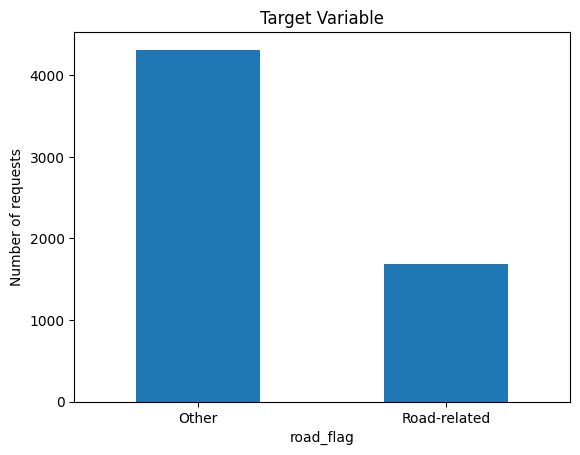

In [ ]:
# The bar chart compares:
# 0 -> Other request
# 1 -> Road-related request
requests_df[
    "road_flag"
].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["Other", "Road-related"],
    rotation=0
)

plt.ylabel(
    "Number of requests"
)

plt.title(
    "Target Variable"
)

plt.show()

# 8. Handle missing predictor values


In [ ]:
df = requests_df[
    [
        "TOWNSHIP",
        "COUNCILDISTRICT",
        "ORIGIN",
        "road_flag" #SELECT 4 FEATURES
    ]
].copy()

print(
    df.isnull().sum()
)
#fills in categorical missing value
df["TOWNSHIP"] = (
    df["TOWNSHIP"]
    .fillna("Unknown")
)

df["COUNCILDISTRICT"] = (
    df["COUNCILDISTRICT"]
    .fillna("Unknown")
)

df["ORIGIN"] = (
    df["ORIGIN"]
    .fillna("Unknown")
)

print()
print(
    "Missing values after cleaning:"
)

print(
    df.isnull().sum()
)

TOWNSHIP           2028
COUNCILDISTRICT    2203
ORIGIN                0
road_flag             0
dtype: int64

Missing values after cleaning:
TOWNSHIP           0
COUNCILDISTRICT    0
ORIGIN             0
road_flag          0
dtype: int64


# 9. One-hot encode predictors and split into X and y


In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "TOWNSHIP",
        "COUNCILDISTRICT",
        "ORIGIN"
    ],
    drop_first=False
)

X = df.drop(
    columns=["road_flag"]
)

y = df["road_flag"]

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X.head()

X shape: (6000, 46)
y shape: (6000,)


,TOWNSHIP_CENTER,TOWNSHIP_DECATUR,TOWNSHIP_FRANKLIN,TOWNSHIP_LAWRENCE,TOWNSHIP_PERRY,TOWNSHIP_PIKE,TOWNSHIP_Unknown,TOWNSHIP_WARREN,TOWNSHIP_WASHINGTON,TOWNSHIP_WAYNE,...,ORIGIN_API,ORIGIN_Email,ORIGIN_MAC Phone,ORIGIN_MAC Spanish Voicemail,ORIGIN_MAC Walk-in,ORIGIN_MNA Office hours,ORIGIN_MNA Phone call or voicemail,ORIGIN_Mail,ORIGIN_Phone,ORIGIN_Web
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


# 10. Train-test split


In [ ]:
# test_size=0.2 -> 80% training / 20% testing.
# random_state=10 -> reproducible split.
# stratify=y -> keeps approximately the same road-related share in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10,
    stratify=y
)

print(
    "Training set:",
    X_train.shape
)

print(
    "Testing set:",
    X_test.shape
)

print()
print("Training target share:")
print(
    y_train.mean()
)

print("Testing target share:")
print(
    y_test.mean()
)

Training set: (4800, 46)
Testing set: (1200, 46)

Training target share:
0.2810416666666667
Testing target share:
0.2808333333333333


# 11. Scale the predictors


In [ ]:
scaler = StandardScaler()

X_train_scaled = (
    scaler.fit_transform(
        X_train
    )
)

X_test_scaled = (
    scaler.transform(
        X_test
    )
)

# 12. Baseline SVM


In [ ]:
baseline_svm = SVC(
    kernel="linear",
    C=1 #baseline setting. gives reference before GridSearchCV
)

baseline_svm.fit(
    X_train_scaled,
    y_train
)

baseline_pred = baseline_svm.predict(
    X_test_scaled
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print(
    "Baseline accuracy:",
    round(
        baseline_accuracy,
        4
    )
)

Baseline accuracy: 0.7525


# 13. Tune C and kernel with GridSearchCV


In [ ]:
svm_parameters = {
    "C": [0.1, 1, 10], #test different C values
    "kernel": [
        "linear",
        "rbf" #test different kernels
    ]
}

base_svm = SVC()

svm_grid = GridSearchCV(
    estimator=base_svm,
    param_grid=svm_parameters,
    cv=5,
    scoring="accuracy"
)
#5-fold cross validation
svm_grid.fit(
    X_train_scaled,
    y_train
)

best_svm = (
    svm_grid.best_estimator_
)

print(
    "Best parameters:",
    svm_grid.best_params_
)

print(
    "Best cross-validation accuracy:",
    round(
        svm_grid.best_score_,
        4
    )
)

Best parameters: {'C': 1, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.7498


# 14. Evaluate the final SVM
=

In [ ]:
y_pred = best_svm.predict(
    X_test_scaled
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print(
    "FINAL SVM TEST PERFORMANCE"
)

print(
    "Accuracy :",
    round(accuracy, 4)
)

print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall   :",
    round(recall, 4)
)

print(
    "F1 Score :",
    round(f1, 4)
)

print()

print(
    "Baseline accuracy:",
    round(
        baseline_accuracy,
        4
    )
)

print(
    "Tuned accuracy:",
    round(
        accuracy,
        4
    )
)

FINAL SVM TEST PERFORMANCE
Accuracy : 0.75
Precision: 0.5693
Recall   : 0.451
F1 Score : 0.5033

Baseline accuracy: 0.7525
Tuned accuracy: 0.75


# 15. Confusion matrix


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Other",
        "Actual Road-related"
    ],
    columns=[
        "Predicted Other",
        "Predicted Road-related"
    ]
)

cm_df

,Predicted Other,Predicted Road-related
Actual Other,748,115
Actual Road-related,185,152


# 16. Performance visualization



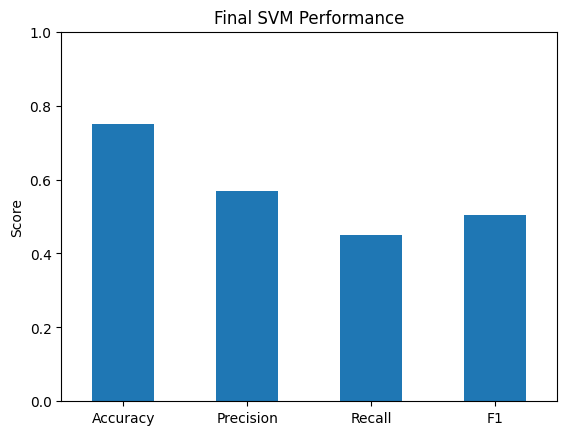

In [ ]:
metric_values = pd.Series({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1
})

metric_values.plot(
    kind="bar"
)

plt.ylim(0, 1)

plt.ylabel(
    "Score"
)

plt.title(
    "Final SVM Performance"
)

plt.xticks(
    rotation=0
)

plt.show()